**Author:** Soumyodipta Majumdar  
**Based on:** MSc Dissertation, University of Liverpool 
**Topic:** Reachability in Attacker–Defender Games with Different Arenas

# Reachability Analysis in Attacker–Defender Robot Games

This notebook explores a simplified reachability problem based on my MSc dissertation, *Reachability in Attacker–Defender Games with Different Arenas* (University of Liverpool, 2024).

The aim is to investigate how an attacker can reach a target state in a two-player robot game played on a two-dimensional integer lattice.

The notebook begins with a basic reachability scenario where only the attacker is allowed to move. Later sections introduce defender actions and analyse their impact on the set of winning states.

In [38]:
import numpy as np
import matplotlib.pyplot as plt

## Case 1: Reachability Without Defender Intervention

Attacker move:

u = (2,1)

Starting from the target state (0,0), reverse reachability is used to generate states from which the attacker can reach the origin through repeated applications of the move vector.

The generated states form the initial winning region.

In [39]:
def generate_winning_states(attacker_move, arena_limit):

    x_move, y_move = attacker_move

    winning_states = []

    x = 0
    y = 0

    while True:

        x -= x_move
        y -= y_move

        if (
            x < -arena_limit
            or x > arena_limit
            or y < -arena_limit
            or y > arena_limit
        ):
            break

        winning_states.append((x, y))

    return winning_states

In [40]:
attacker_move = (2,1)

arena_limit = 20

winning_states = generate_winning_states(
    attacker_move,
    arena_limit
)

winning_states

[(-2, -1),
 (-4, -2),
 (-6, -3),
 (-8, -4),
 (-10, -5),
 (-12, -6),
 (-14, -7),
 (-16, -8),
 (-18, -9),
 (-20, -10)]

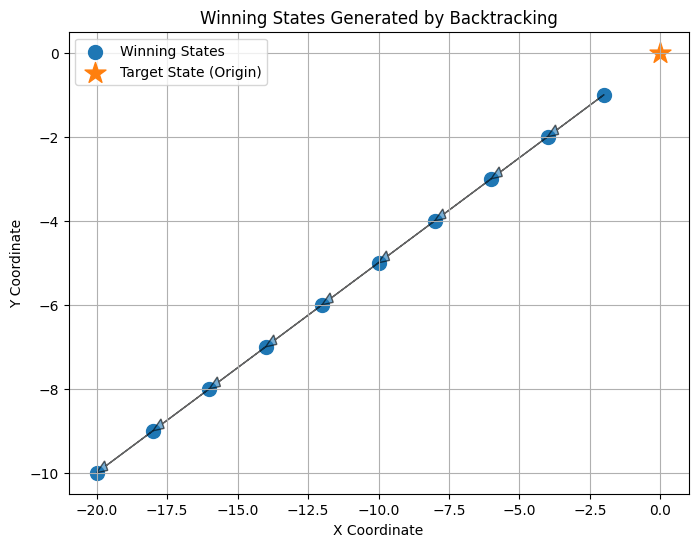

In [41]:
x_vals = [p[0] for p in winning_states]
y_vals = [p[1] for p in winning_states]

plt.figure(figsize=(8,6))

plt.scatter(
    x_vals,
    y_vals,
    s=100,
    label="Winning States"
)

plt.scatter(
    [0],
    [0],
    s=250,
    marker='*',
    label="Target State (Origin)"
)

for i in range(len(winning_states)-1):

    x1, y1 = winning_states[i]
    x2, y2 = winning_states[i+1]

    plt.arrow(
        x1,
        y1,
        x2 - x1,
        y2 - y1,
        length_includes_head=True,
        head_width=0.25,
        alpha=0.6
    )

plt.legend()

plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.title("Winning States Generated by Backtracking")

plt.grid(True)

plt.show()

## Case 2: Introducing Defender Actions

A defender move is added to the game.

Defender move:

d = (1,0)

The defender modifies states belonging to the winning region. The resulting positions are compared with the original attacker states to examine how defender intervention changes reachability.

In [42]:
def generate_defender_states(winning_states, defender_move):

    dx, dy = defender_move

    defender_states = []

    for x, y in winning_states:

        defender_states.append(
            (x + dx, y + dy)
        )

    return defender_states

In [43]:
defender_move = (1,0)

defender_states = generate_defender_states(
    winning_states,
    defender_move
)

defender_states[:5]

[(-1, -1), (-3, -2), (-5, -3), (-7, -4), (-9, -5)]

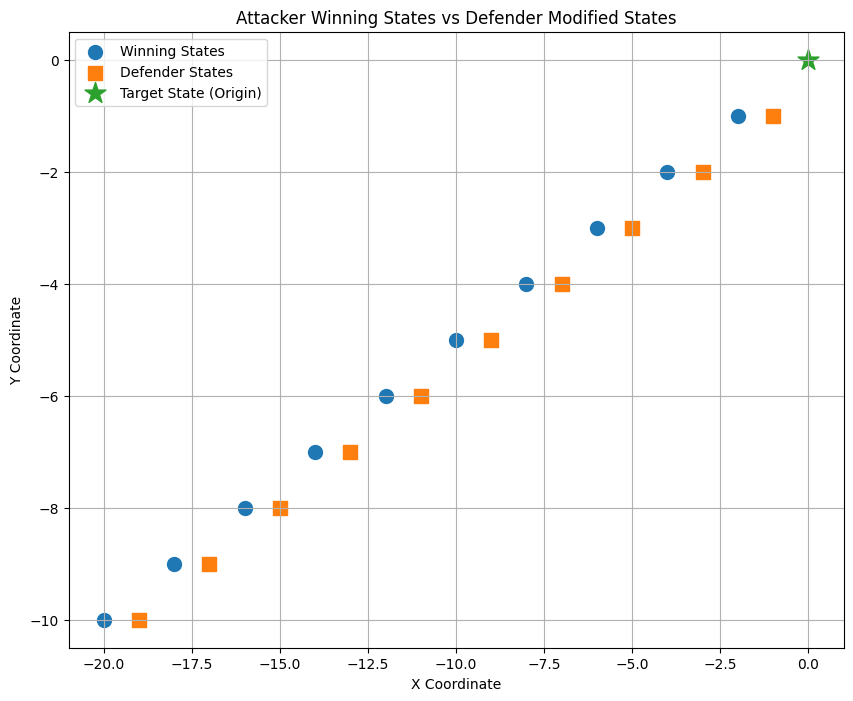

In [44]:
import matplotlib.pyplot as plt

# Winning states
x_win = [p[0] for p in winning_states]
y_win = [p[1] for p in winning_states]

# Defender-modified states
x_def = [p[0] for p in defender_states]
y_def = [p[1] for p in defender_states]

plt.figure(figsize=(10,8))

plt.scatter(
    x_win,
    y_win,
    s=100,
    label="Winning States"
)

plt.scatter(
    x_def,
    y_def,
    s=100,
    marker="s",
    label="Defender States"
)

plt.scatter(
    [0],
    [0],
    s=250,
    marker="*",
    label="Target State (Origin)"
)

plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")

plt.title(
    "Attacker Winning States vs Defender Modified States"
)

plt.grid(True)

plt.legend()

plt.show()

## Case 3: State Classification After Defence

Each defender-modified state is tested for reachability.

Starting from the modified position, the attacker repeatedly applies its move vector and attempts to return to the origin.

States that can still reach the target are classified as winning states. All remaining states are classified as losing states.

In [45]:
def can_reach_origin(state, attacker_move):

    x, y = state
    ax, ay = attacker_move

    while x <= 0 and y <= 0:

        if (x, y) == (0, 0):
            return True

        x += ax
        y += ay

    return False

In [46]:
winning_after_defence = []
losing_after_defence = []

for state in defender_states:

    if can_reach_origin(state, attacker_move):
        winning_after_defence.append(state)

    else:
        losing_after_defence.append(state)

In [47]:
print("Winning States After Defence:")
print(winning_after_defence)

print("\nLosing States After Defence:")
print(losing_after_defence)

print("\nNumber of Winning States:", len(winning_after_defence))
print("Number of Losing States:", len(losing_after_defence))

Winning States After Defence:
[]

Losing States After Defence:
[(-1, -1), (-3, -2), (-5, -3), (-7, -4), (-9, -5), (-11, -6), (-13, -7), (-15, -8), (-17, -9), (-19, -10)]

Number of Winning States: 0
Number of Losing States: 10


In [48]:
import pandas as pd

results = pd.DataFrame({
    "State": defender_states,
    "Classification": [
        "Winning" if state in winning_after_defence
        else "Losing"
        for state in defender_states
    ]
})

results

,State,Classification
0,"(-1, -1)",Losing
1,"(-3, -2)",Losing
2,"(-5, -3)",Losing
3,"(-7, -4)",Losing
4,"(-9, -5)",Losing
5,"(-11, -6)",Losing
6,"(-13, -7)",Losing
7,"(-15, -8)",Losing
8,"(-17, -9)",Losing
9,"(-19, -10)",Losing


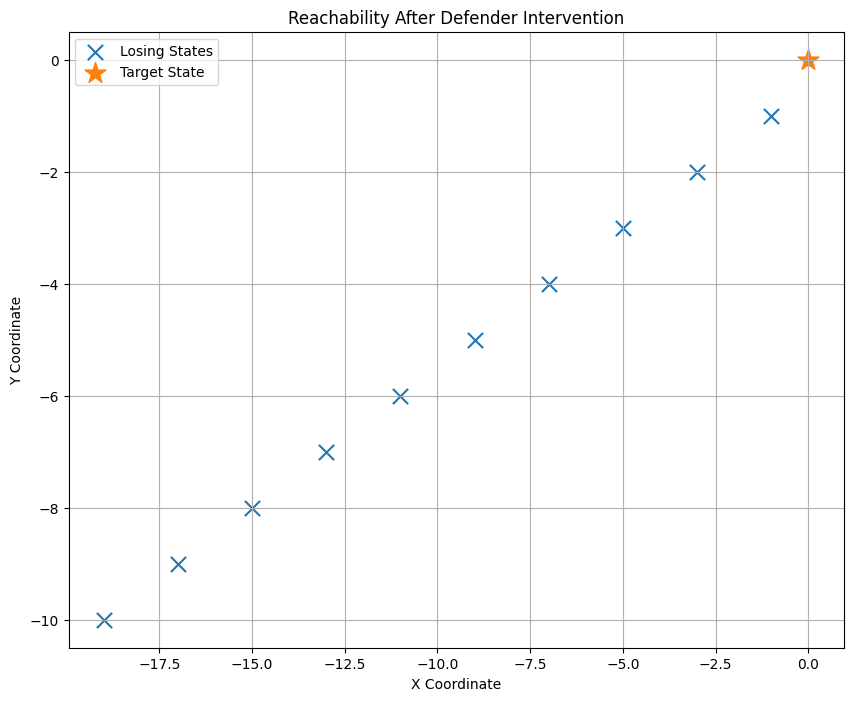

In [49]:
plt.figure(figsize=(10,8))

if winning_after_defence:

    plt.scatter(
        [x for x,y in winning_after_defence],
        [y for x,y in winning_after_defence],
        s=120,
        label="Winning States"
    )

if losing_after_defence:

    plt.scatter(
        [x for x,y in losing_after_defence],
        [y for x,y in losing_after_defence],
        s=120,
        marker="x",
        label="Losing States"
    )

plt.scatter(
    [0],
    [0],
    s=250,
    marker="*",
    label="Target State"
)

plt.title(
    "Reachability After Defender Intervention"
)

plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")

plt.grid(True)
plt.legend()

plt.show()

### Discussion

For the selected configuration, all defender-modified states were classified as losing states.

The defender displacement moves states away from the attacker's reachability path, preventing a return to the origin through repeated applications of the attacker move vector.

In this example, a single defender action eliminates the winning region.

## Case 4: Comparing Attacker Strategies

The previous sections considered a single attacker move.

To examine how attacker behaviour influences reachability, the analysis is repeated using multiple move vectors within the same bounded arena.

For each configuration, reverse reachability is performed from the target state and the resulting winning region is recorded.

In [50]:
attacker_moves = [
    (1,1),
    (2,1),
    (3,2),
    (4,2)
]

arena_limit = 20

In [51]:
comparison_results = []

for move in attacker_moves:

    states = generate_winning_states(
        move,
        arena_limit
    )

    comparison_results.append({
        "Attacker Move": str(move),
        "Winning States": len(states)
    })

In [52]:
import pandas as pd

comparison_df = pd.DataFrame(
    comparison_results
)

comparison_df

,Attacker Move,Winning States
0,"(1, 1)",20
1,"(2, 1)",10
2,"(3, 2)",6
3,"(4, 2)",5


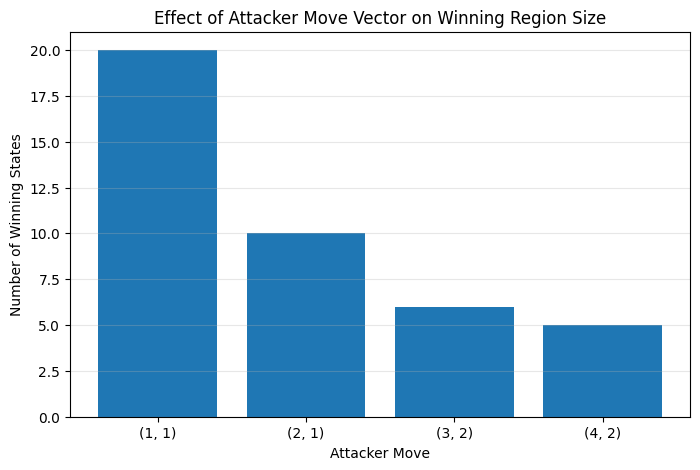

In [53]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Attacker Move"],
    comparison_df["Winning States"]
)

plt.title(
    "Effect of Attacker Move Vector on Winning Region Size"
)

plt.xlabel("Attacker Move")
plt.ylabel("Number of Winning States")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

In [54]:
attacker_moves = [
    (1,1),
    (2,1),
    (3,2),
    (4,2)
]

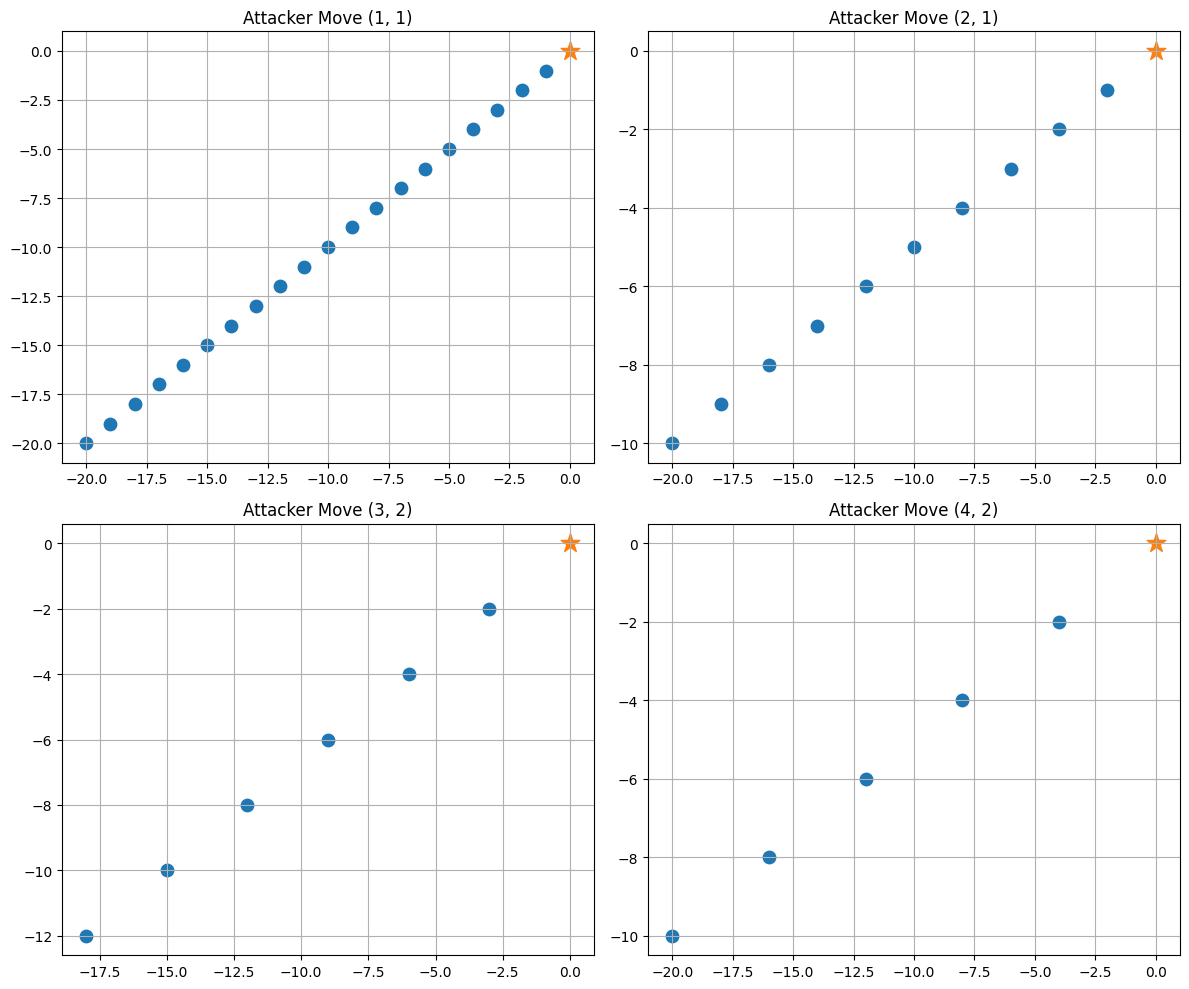

In [55]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12,10)
)

for ax, move in zip(
    axes.flatten(),
    attacker_moves
):

    states = generate_winning_states(
        move,
        arena_limit
    )

    x = [s[0] for s in states]
    y = [s[1] for s in states]

    ax.scatter(
        x,
        y,
        s=80
    )

    ax.scatter(
        [0],
        [0],
        s=200,
        marker='*'
    )

    ax.set_title(
        f"Attacker Move {move}"
    )

    ax.grid(True)

plt.tight_layout()
plt.show()

### Discussion

The number of winning states decreases as the attacker move vector increases in magnitude.

Larger moves produce sparser reachability structures and fewer reachable states within the fixed arena boundary.

This relationship is visible both in the winning-state counts and in the spatial distribution of the generated regions.

## Conclusion

This notebook explored reachability in attacker-defender robot games using reverse reachability analysis.

The experiments showed that:

- Reverse reachability can be used to construct winning regions.
- Defender intervention can remove reachability for the configurations examined.
- Larger attacker move vectors generate smaller winning regions within a bounded arena.

Although simplified, the implementation captures several of the core ideas explored in the dissertation.

## Future Work

Several extensions could be explored in future versions:

- Multiple defender actions
- Alternative arena structures
- Graph-based state exploration
- Additional attacker and defender strategies
- Higher-dimensional game arenas

These additions would provide a closer approximation to the full attacker-defender framework studied in the dissertation.